# 拡散モデルを体験する

## 1. これからやること

ここでは、[DDPM](https://arxiv.org/pdf/2006.11239)という拡散モデルを用いた画像生成の過程を体験します。
デモには [Smithsonian Butterflies](https://huggingface.co/datasets/huggan/smithsonian_butterflies_subset)（スミソニアン博物館、CC0）データセットで学習された学習済みモデル [`gnokit/ddpm-butterflies-64`](https://huggingface.co/gnokit/ddpm-butterflies-64)（Apache-2.0 ライセンス）を使用します。

### 拡散モデルのお気持ち

そもそも拡散モデルとはなんなのでしょうか？
拡散モデルとは、
- データにノイズを**付加**していく過程 (順拡散過程)
- ノイズを**除去**していく過程 (逆拡散過程)
の2つの過程により、データの生成を実現するモデルのことです。

![DDPM diffusion process](https://sushant-kumar.com/blog/ddpm-diffusion-process.png)

(引用: sushant-kumar, https://sushant-kumar.com/blog/ddpm-denoising-diffusion-probabilistic-models)

図のように、順拡散過程では画像データ$x_0$にノイズを時刻が進むにつれて徐々に付加していくことで、最終的に完全なノイズ$x_T$を得ることができます。
一方、逆拡散過程では、ノイズが付加された画像データ$x_t$からノイズを除去していくことで、最終的に元の画像データ$x_0$を復元することを目指します。

拡散モデルの**学習**とは、この逆拡散過程を学習することを指します。
つまり、ノイズだらけの画像データ$x_t$からノイズを除去していく過程を学習することで、元の画像データ$x_0$を復元する能力を獲得させることが目的となります。

この能力を獲得したモデルに、ランダムにサンプリングしたノイズデータを入力することで、逆拡散過程を通じて画像データを生成することができるようになります。

## 2. 逆拡散過程を可視化してみる

逆拡散過程により、データがどのように生成されていくのかを可視化してみましょう。
以下のコードブロックを順に実行してみてください。

### セットアップ

In [1]:
%%capture
!pip install diffusers accelerate

In [2]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from diffusers import DDPMPipeline
from IPython.display import display, Image as IPImage

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


### モデルのロード

In [3]:
pipeline = DDPMPipeline.from_pretrained("gnokit/ddpm-butterflies-64", use_safetensors=True, variant="fp16")
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = pipeline.to(device)

print(f"Model loaded  —  device: {device}")
print(f"Image size: {pipeline.unet.config.sample_size}px")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded  —  device: cuda
Image size: 64px


### 生成

In [8]:
N_IMAGES = 9
SEED     = 42
N_FRAMES = 20  # GIF のフレーム数

unet      = pipeline.unet
scheduler = pipeline.scheduler
image_size = unet.config.sample_size

scheduler.set_timesteps(1000)
torch.manual_seed(SEED)
x = torch.randn((N_IMAGES, 3, image_size, image_size), device=device)

# キャプチャするタイムステップを均等に選ぶ
total_steps = len(scheduler.timesteps)
capture_at  = set(range(0, total_steps, total_steps // N_FRAMES))
capture_at.add(total_steps - 1)
frames = []

print("Running backward diffusion … (this may take a minute)")
for i, t in enumerate(scheduler.timesteps):
    with torch.no_grad():
        noise_pred = unet(x, t).sample
    x = scheduler.step(noise_pred, t, x).prev_sample

    if i in capture_at:
        imgs = ((x.clamp(-1, 1) + 1) / 2 * 255).byte().cpu().numpy()
        nrow = 3
        h = w = image_size
        grid = np.zeros((nrow * h, nrow * w, 3), dtype=np.uint8)
        for idx in range(N_IMAGES):
            r, c = divmod(idx, nrow)
            grid[r*h:(r+1)*h, c*w:(c+1)*w] = imgs[idx].transpose(1, 2, 0)
        frames.append(Image.fromarray(grid))

# 保存
out_gif = Path("/content/generation.gif")
out_png = Path("/content/generation.png")
frames[-1].save(out_png)

# 各フレームの表示時間を設定（最後だけ3秒 = 3000ms にする）
durations = [100] * (len(frames) - 1) + [3000]
frames[0].save(out_gif, save_all=True, append_images=frames[1:], duration=durations, loop=0)
print("Done!")

Running backward diffusion … (this may take a minute)
Done!


逆拡散過程の様子

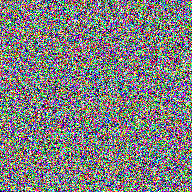

In [9]:
display(IPImage(filename="/content/generation.gif", width=500))

## 3. おわりに

今回は、拡散モデルの基本的な考え方と、逆拡散過程の様子を確認してみました。

ところで、逆拡散過程では、ノイズが付加された画像データからノイズを除去していくことで、元の画像データを復元することを目指すと説明しました。
しかし、なぜノイズを除去していくことで、元の画像データを復元することができるのでしょうか？ 直感的には妥当なアイデアのように思えますが、
数学的に考えると、ノイズを予測することで元の画像データの確率分布を学習できるというのは非自明なことのように思えます。

このあたりの理論的な背景については、[ネットの解説記事](https://zenn.dev/doctorin/articles/diffusion_models#%E3%81%AF%E3%81%98%E3%82%81%E3%81%AB)
や、書籍[1](https://www.amazon.co.jp/%E6%8B%A1%E6%95%A3%E3%83%A2%E3%83%87%E3%83%AB-%E3%83%87%E3%83%BC%E3%82%BF%E7%94%9F%E6%88%90%E6%8A%80%E8%A1%93%E3%81%AE%E6%95%B0%E7%90%86-%E5%B2%A1%E9%87%8E%E5%8E%9F-%E5%A4%A7%E8%BC%94/dp/400006343X?&linkCode=sl1&tag=doctorin-22&linkId=990451e5c4da9edadbeb974a51d37400&language=ja_JP&ref_=as_li_ss_tl),
[2](https://www.oreilly.co.jp/books/9784814400591/)
などで詳しく解説されているので、興味のある方はぜひ読んでみてください。

もし今回のデモが「面白い！」と感じた方は、ぜひkaggle班で共に機械学習の世界を探求してみましょう！